In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
y = pd.read_parquet('./data/processed/us_4q_fred_y.parquet')
y.head()

,Infl_yoy,IP_yoy,Unrate_yoy
date,,,
1961-01-01,0.015876,-0.088327,0.238411
1961-02-01,0.014515,-0.080604,0.362905
1961-03-01,0.014515,-0.065519,0.245122
1961-04-01,0.009099,-0.037214,0.297252
1961-05-01,0.009089,-0.020786,0.330854


In [44]:
last_date = pd.to_datetime(y.index[-1])
last_y = float(y['Unrate_yoy'].iloc[-1])

future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=4, freq='MS')
forecast_index = pd.DatetimeIndex([last_date]).append(future_dates)

# Realistic right-skewed unemployment distribution:
#   - Left tail is capped: unemployment can't fall much if already low;
#     the best plausible scenario is a modest decline in the rate
#   - Right tail is fat: rare but severe recession spikes (GFC: +80 log pts,
#     COVID: +144 log pts over 4Q) pull the mean up sharply
#   - Right skew => mean > median (fat right tail inflates the mean)
#   - The mean alone looks alarming; the median tells a more sober story

fc = pd.DataFrame(
    {
        # Mean: pulled well above median by the fat recession right tail
        'Unrate_yoy': [last_y,  0.10,  0.16,  0.21,  0.25],
        # Q5: left tail capped — mild labour market easing in best case
        'Q5':         [last_y - 0.01, -0.06, -0.07, -0.08, -0.08],
        # Q25: unemployment roughly flat or slightly down
        'Q25':        [last_y,        0.01,  0.01,  0.01,  0.02],
        # Q50 (median): modest, close to current trend; much lower than mean
        'Q50':        [last_y + 0.01,  0.06,  0.08,  0.09,  0.09],
        # Q75: more notable rise but still a normal-cycle slowdown
        'Q75':        [last_y + 0.02,  0.17,  0.22,  0.26,  0.28],
        # Q95: right tail fat — recession-level spike (unemployment could near-double)
        'Q95':        [last_y + 0.03,  0.42,  0.60,  0.72,  0.80],
    },
    index=forecast_index,
)
fc.index.name = 'date'

In [26]:
fc

,IP_yoy,Q5,Q25,Q50,Q75,Q95
date,,,,,,
2024-12-01,-0.002745,-0.007745,-0.004745,-0.002745,-0.001745,0.000255
2025-01-01,0.012000,-0.010000,-0.004000,0.000000,0.007000,0.020000
2025-02-01,0.022000,-0.022000,-0.010000,-0.003000,0.011000,0.030000
2025-03-01,0.032000,-0.032000,-0.015000,-0.006000,0.015000,0.040000
2025-04-01,0.039000,-0.040000,-0.020000,-0.010000,0.020000,0.052000


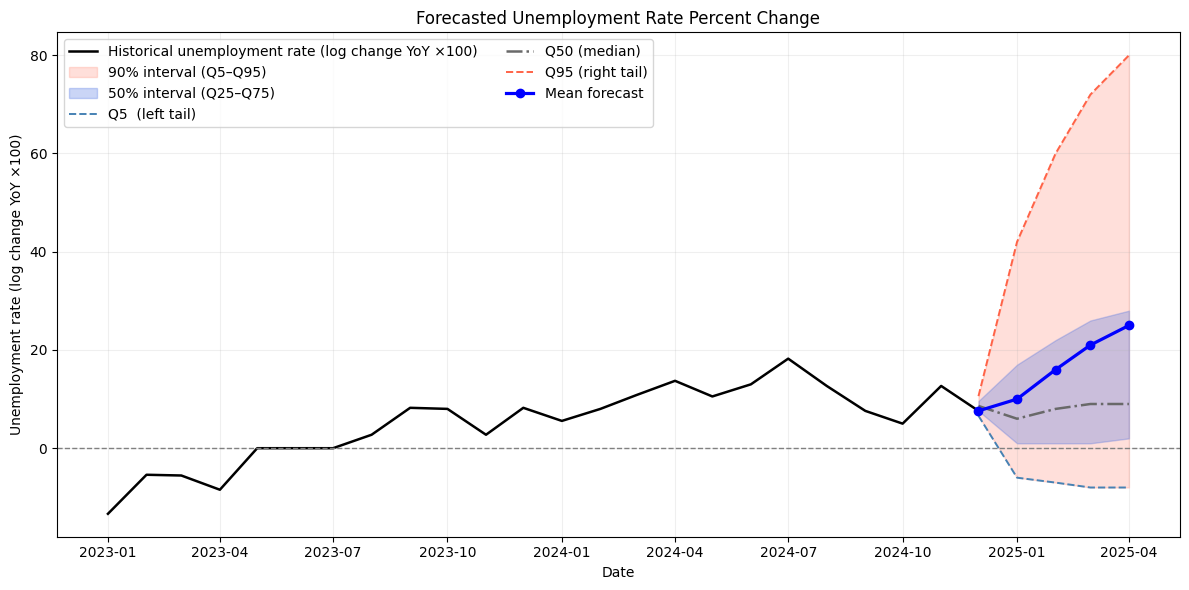

In [50]:
plot_fc_dist = True

fig, ax = plt.subplots(figsize=(12, 6))

# Historical tail for context
hist = y['Unrate_yoy'].iloc[-24:] * 100
ax.plot(hist.index, hist.values, color='black', linewidth=1.8,
        label='Historical unemployment rate (log change YoY ×100)')

x = fc.index

if plot_fc_dist:
    # 90% fan: asymmetric — right tail extends far above the median
    ax.fill_between(x, fc['Q5'] * 100, fc['Q95'] * 100,
                    color='tomato', alpha=0.20, label='90% interval (Q5–Q95)')
    # 50% fan: IQR tightly clustered near median, far below the mean
    ax.fill_between(x, fc['Q25'] * 100, fc['Q75'] * 100,
                    color='royalblue', alpha=0.28, label='50% interval (Q25–Q75)')

    # Quantile paths
    ax.plot(x, fc['Q5']  * 100, color='steelblue', linestyle='--', linewidth=1.4,
            label='Q5  (left tail)')
    ax.plot(x, fc['Q50'] * 100, color='dimgray',   linestyle='-.', linewidth=1.8,
            label='Q50 (median)')
    ax.plot(x, fc['Q95'] * 100, color='tomato',    linestyle='--', linewidth=1.4,
            label='Q95 (right tail)')

# Mean forecast: pulled up by fat right tail, appears alarming
ax.plot(x, fc['Unrate_yoy'] * 100, color='blue', linewidth=2.3, marker='o',
        label='Mean forecast')

# Zero-change reference
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# if plot_fc_dist:
    # ax.annotate(
    #     'Right-skewed distribution:\n'
    #     '  • Left tail capped (unemployment can\'t fall much)\n'
    #     '  • Fat right tail (recession spike: Q95 ≈ +80 log pts)\n'
    #     '  • Mean > median  ⟹  mean looks alarming\n'
    #     '  • Median tells a more sober story: modest rise',
    #     xy=(x[3], fc['Q75'].iloc[3] * 100),
    #     xytext=(x[0] - pd.DateOffset(months=4), 45),
    #     arrowprops=dict(arrowstyle='->', color='black', lw=1),
    #     fontsize=9,
    #     bbox=dict(boxstyle='round,pad=0.35', fc='lightyellow', ec='black', alpha=0.95),
    # )

ax.set_xlabel('Date')
ax.set_ylabel('Unemployment rate (log change YoY ×100)')
ax.set_title('Forecasted Unemployment Rate Percent Change')
ax.legend(loc='upper left', ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'./latex/Figures/forecast_fan_example_dist{plot_fc_dist}.png', dpi=300)
plt.show()

date
2024-05-01    0.1054
2024-06-01    0.1301
2024-07-01    0.1823
2024-08-01    0.1268
2024-09-01    0.0760
2024-10-01    0.0500
2024-11-01    0.1268
2024-12-01    0.0760
Name: Unrate_yoy, dtype: float64

## Model interpretation investigation

In [4]:
data = pd.read_parquet('./data/processed/us_4q_fred_x.parquet')

In [5]:
data.shape

(768, 122)

<Axes: xlabel='date'>

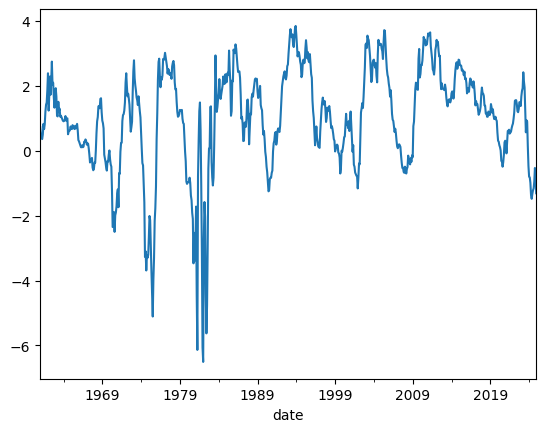

In [10]:
data.loc[:,'T10YFFM'].plot()

<Axes: xlabel='date'>

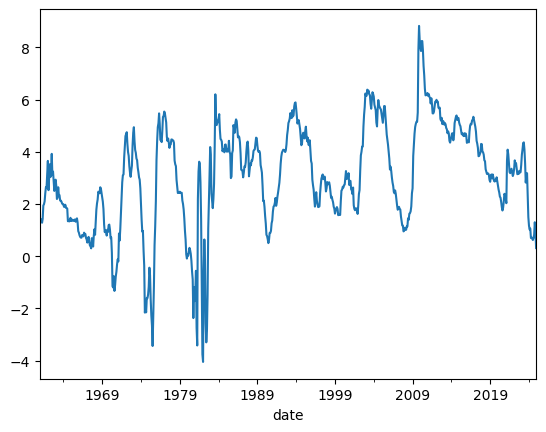

In [8]:
baaffm = data.loc[:,'BAAFFM']
baaffm.plot()

<Axes: xlabel='date'>

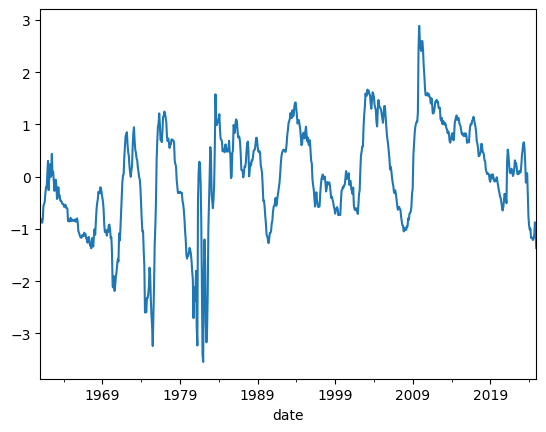

In [9]:
z_baaffm = (baaffm - baaffm.mean()) / baaffm.std() 
z_baaffm.plot()